# Test-Szenario A1
Wie gut können LLMs Feebdack zu den gegebenen Antworten geben?
_Könnte **Test-Szenarien S7, S8, S9** abdecken_

_Anwendbar auch für Test-Szenarien 3 und 4_
- _**Test-Szenario A3**: Evaluierung von verbesserten Spracheingaben -> wie oft wird das Gesprochene wie erwartet bewertet?_
- _**Test-Szenario A4**: Evaluierung von invarianten Spracheingaben -> wie oft, trotz Fehlern in der Eingabe, wird das Gesprochene wie erwartet bewertet? (deckt **Test-Szenario S3** ab)_
- _**Test-Szenario S2**: Erfolgt eine Ergänzungs-/Rückfrage wie erwartet?_

## Load Input Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dir_path = Path(".")  # current directory
keep_cols = [
    "question_de",
    "answer_de",
    "max_points",
    "keywords",
    "transkript_stt_model",
    "human_score",
    "human_feedback",
    "rueckfrage",
    "error_type",
]

dfs = []
for fp in sorted(dir_path.glob("*.tsv")):
    df_tmp = pd.read_csv(fp, sep="\t", dtype=str)
    df_tmp = df_tmp.reindex(columns=keep_cols)  # keeps order, fills missing with NA
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)  # appends; duplicates are kept
df["max_points"] = df["max_points"].str.replace(",", ".").astype(float)
df["human_score"] = df["human_score"].str.replace(",", ".").astype(float)
df["error_type"] = df["error_type"].astype(int)
df["rueckfrage"] = df["rueckfrage"].astype(int)

# check for column names: question_text, transkript_stt_model, gold_answer, maximal_score, human_score, human_feedback
df.head()

,question_de,answer_de,max_points,keywords,transkript_stt_model,human_score,human_feedback,rueckfrage,error_type
0,Was ist der Zweck von t-Tests in der EDA?,"T-Tests in der EDA werden verwendet, um die Mi...",6.0,t-Tests; unabhängige Stichproben; bekannter We...,EDA steht für explorative Datenanalyse. Tests ...,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
1,Was ist der Zweck nicht-parametrischer Tests i...,Nicht-parametrische Tests in der EDA werden ve...,4.0,nicht-parametrische Tests; EDA; Annahmen param...,Nicht parametrische Tests in der idea werden v...,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
2,Was ist der Zweck der explorativen Faktorenana...,Die explorative Faktorenanalyse (EFA) im Rahme...,4.0,explorative Faktorenanalyse; EDA; zugrunde lie...,"Der Zweck besteht darin, die Ursache oder aber...",4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
3,Was ist der Unterschied zwischen EFA und Haupt...,EFA und PCA sind beide Verfahren zur Reduktion...,6.0,EFA; PCA; Dimensionality Reduction; explorativ...,"Da ich nicht weiß wofür Fa steht, kann ich lei...",0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3,2
4,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm in der hierarchischen Clustera...,6.0,Dendrogramm; hierarchische Beziehungen; Mergin...,Ein Dendrogramm hilft in der hierarchischen Cl...,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2,2


In [2]:
len(df)

95

## Call LLMs

In [3]:
from llm_handler import LLMHandler
import json

# TODO: Write prompt for evaluation
prompt = """
Du bekommst eine Prüfungsfrage, die Antwort eines Studenten darauf, die Musterlösung zu der Frage und die maximal erreichbare Punktzahl für eine richtige Antwort.
Deine Aufgabe ist es, die Antwort des Studenten mit der Musterlösung zu vergleichen und diese zu bewerten.

Dabei sollst du dich an folgendem Leitfaden orientieren:
1) Hat der Student den Sachverhalt fachlich korrekt dargestellt, ohne wesentliche Fehler oder falsche Zusammenhänge?
2) Verwendet der Student die relevanten Schlüsselbegriffe korrekt und im richtigen Kontext? Schau dabei auf folgende Liste der wichtigsten Fachbegriffe: {keywords}.
3) Geht der Student auf alle wesentlichen Aspekte der Fragestellung ein oder bleiben zentrale Punkte unbeantwortet?
4) Werden die angesprochenen Konzepte klar voneinander unterschieden und nicht miteinander vermischt?
5) Ist die Antwort logisch aufgebaut, nachvollziehbar formuliert und für den Prüfer gut verständlich?
6) Soll vom Prüfer eine Rückfrage gestellt werden, um auf Lücken zu prüfen?

Deine Ausgabe soll aus folgenden Elementen bestehen:
- **llm_feedback**: In diesem Feld schreibst du die Bewertung zur Antwort des Studenten. Dabei gehst du auf jeden der oben genannten Punkte ein und formulierst anschließend einen Fließtext daraus. Beschränke dich bei dem Fließtext auf maximal 4-5 Sätze.
- **llm_rating**: Hier vergibst du die Punktzahl, die deiner Meinung nach die Antwort des Studenten wiederspiegelt. Du kannst die Punkte in 0,5 Schritten vergeben. Die maximal vergebbare Punktzahl ist {max_score}.
- **rueckfrage**: Du füllst dieses Feld mit einem Integer aus. Dieser Integer kann 0, 1, 2 oder 3 sein. 0 bedeutet, dass keine Rückfrage notwendig ist. 1 bedeutet, dass eine Rückfrage notwendig ist, die sich auf nicht genannte Fach- bzw. Schlüsselbegriffe bezieht. 2 bedeutet, dass eine Rückfrage gestellt wird und sich auf eine fehlende Teilantwort bezieht. 3 bedeutet, dass sich die gestellte Rückfrage auf einem Teil der falschen Antwort bezieht.

Frage:
{question}

Studentenantwort:
{student_answer}

Musterlösung:
{correct_answer}

Für diese Frage gibt es maximal {max_score} Punkte.

<Antwortformat>
```json
{{
"llm_feedback": "<Hier antwortest du auf die Antwort des Studenten und gibts ihm Feedback entsprechend der Analysepunkte. Die Antwort ist ein Text, es gibt keine JSON-Struktur>",
"llm_rating": "<Gesamtrating, maximale Punkte: {max_score}, gerundet auf eine Nachkommastelle>",
"rueckfrage": "<0 | 1 | 2 | 3>"
}}```
"""

In [4]:
import time


def _results_current_model(
    llm: LLMHandler, prompt: str, df: pd.DataFrame
) -> pd.DataFrame:
    llm_results = []
    for _, row in df.iterrows():
        prompt_filled = prompt.format(
            question=row["question_de"],
            student_answer=row["transkript_stt_model"],
            keywords=row["keywords"],
            correct_answer=row["answer_de"],
            max_score=row["max_points"],
        )
        while True:
            try:
                print(f"Try processing row {_}")
                answer = llm.call_llm(prompt=prompt_filled)
                if not isinstance(answer, dict):
                    raise ValueError("LLM response is not a dictionary")
                answer["question"] = row["question_de"]
                answer["student_answer"] = row["transkript_stt_model"]
                answer["correct_answer"] = row["answer_de"]
                answer["keywords"] = row["keywords"]
                answer["max_score"] = row["max_points"]
                answer["human_score"] = row["human_score"]
                answer["human_feedback"] = row["human_feedback"]
                answer["rueckfrage_human"] = row["rueckfrage"]
                llm_results.append(answer)
                with open("checkpoint_transcript.json", "a", encoding="utf-8") as f:
                    f.write(json.dumps(answer, ensure_ascii=False) + "\n")
                break
            except Exception as e:
                print(f"Error processing row {_}: {e}. Retrying in 5 seconds...")
                time.sleep(5)
    return pd.DataFrame(llm_results)

In [5]:
# models = ["gemma3:27b", "gemma3:4b", "deepseek-r1:8b", "llama3.1:latest", "command-r7b:latest", "mixtral:latest",
#  "mistral-small3.1:latest", "llama3.3:latest", "phi4:latest"]

# for testing purposes
models = ["llama3.1:latest", "command-r7b:latest", "mixtral:latest"]

dfs = []

for model in models:
    llm_handler = LLMHandler(model=model)

    df_model = _results_current_model(llm_handler, prompt, df)
    df_model["model"] = model
    dfs.append(df_model)

final_df = pd.concat(dfs, ignore_index=True)

Try processing row 0
Error processing row 0: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 0
Error processing row 0: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 0
Try processing row 1
Try processing row 2
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error proces

In [6]:
final_df.to_csv("llm_evaluation_results_stt_second_try.csv", index=False)

## Evaluate LLM Answers

### Semantic Similarity of LLM Feedback with Human Feedback

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import torch

device = torch.device("cpu")

final_df = pd.read_csv("llm_evaluation_combined_stt.csv")

semantic_judge = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")


def _semantic_similarity(a: str, b: str) -> float:
    """Calculate the semantic similarity between two texts using cosine similarity of their embeddings.

    Args:
        a (str): The first text to compare.
        b (str): The second text to compare.

    Returns:
        float: A float value between -1 and 1 indicating the semantic similarity between the two texts.
    """
    emb_a = semantic_judge.encode(a, convert_to_tensor=True).detach().cpu()
    emb_b = semantic_judge.encode(b, convert_to_tensor=True).detach().cpu()

    sim = cosine_similarity(emb_a.reshape(1, -1).numpy(), emb_b.reshape(1, -1).numpy())[
        0
    ][0]

    return float(sim)

/Users/aleks/Desktop/FernUni_Hagen/EchoLearnBrainstorming/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
final_df

,id,question,answer,llm_feedback,llm_rating,rueckfrage,student_answer,correct_answer,keywords,max_score,human_score,human_feedback,rueckfrage_human,model
0,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten erfasst die grundleg...,3.5,1.0,dieser trade off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.5,Die Antwort stellt den grundlegenden Sachverha...,2.0,gemma3:27b
1,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten zeigt ein grundlegen...,3.0,3.0,Dieser Trade Off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.0,"1) Die Antwort wurde, bis auf eine Verwechslun...",3.0,gemma3:27b
2,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten zeigt ein grundlegen...,4.0,2.0,Dieser Trade Off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,2.0,Die Antwort erkennt den Trade-off und nennt Bi...,3.0,gemma3:27b
3,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten benennt den Bias-Var...,3.5,1.0,dieser trade off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.5,Die Antwort stellt den grundlegenden Sachverha...,2.0,gemma3:4b
4,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten erfasst den Kern des...,4.0,1.0,Dieser Trade Off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.0,"1) Die Antwort wurde, bis auf eine Verwechslun...",3.0,gemma3:4b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten stellt den Sachverha...,4.0,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,llama3.3:latest
851,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten ist fachlich korrekt...,4.0,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,phi4:latest
852,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten enthält die richtige...,3.5,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,llama3.1:latest
853,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten ist korrekt und klar...,4.0,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,command-r7b:latest


In [5]:
final_df["semantic_similarity"] = final_df.apply(
    lambda row: _semantic_similarity(row["llm_feedback"], row["human_feedback"]), axis=1
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### MAE for LLM Scores and Human Scores

In [10]:
import numpy as np

final_df["llm_rating"] = final_df["llm_rating"].str.replace(",", ".")
final_df["llm_rating"] = (
    final_df["llm_rating"].str.replace("2.5/4.0", "2.5").astype(float)
)
final_df["abs_error"] = np.abs(
    final_df["human_score"] - final_df["llm_rating"].astype(float)
)
final_df["error_perf"] = 1 - (final_df["abs_error"] / final_df["max_score"])

In [11]:
final_df["grade_ok_05"] = final_df["abs_error"] <= 0.5
final_df["grade_ok_10"] = final_df["abs_error"] <= 1.0

grade_quality = final_df.groupby("model").agg(
    sem_sim_mean=("semantic_similarity", "mean"),
    exact_rate=("abs_error", lambda x: (x == 0).mean()),
    ok_05_rate=("grade_ok_05", "mean"),
    ok_10_rate=("grade_ok_10", "mean"),
)

## Comparison and metrics

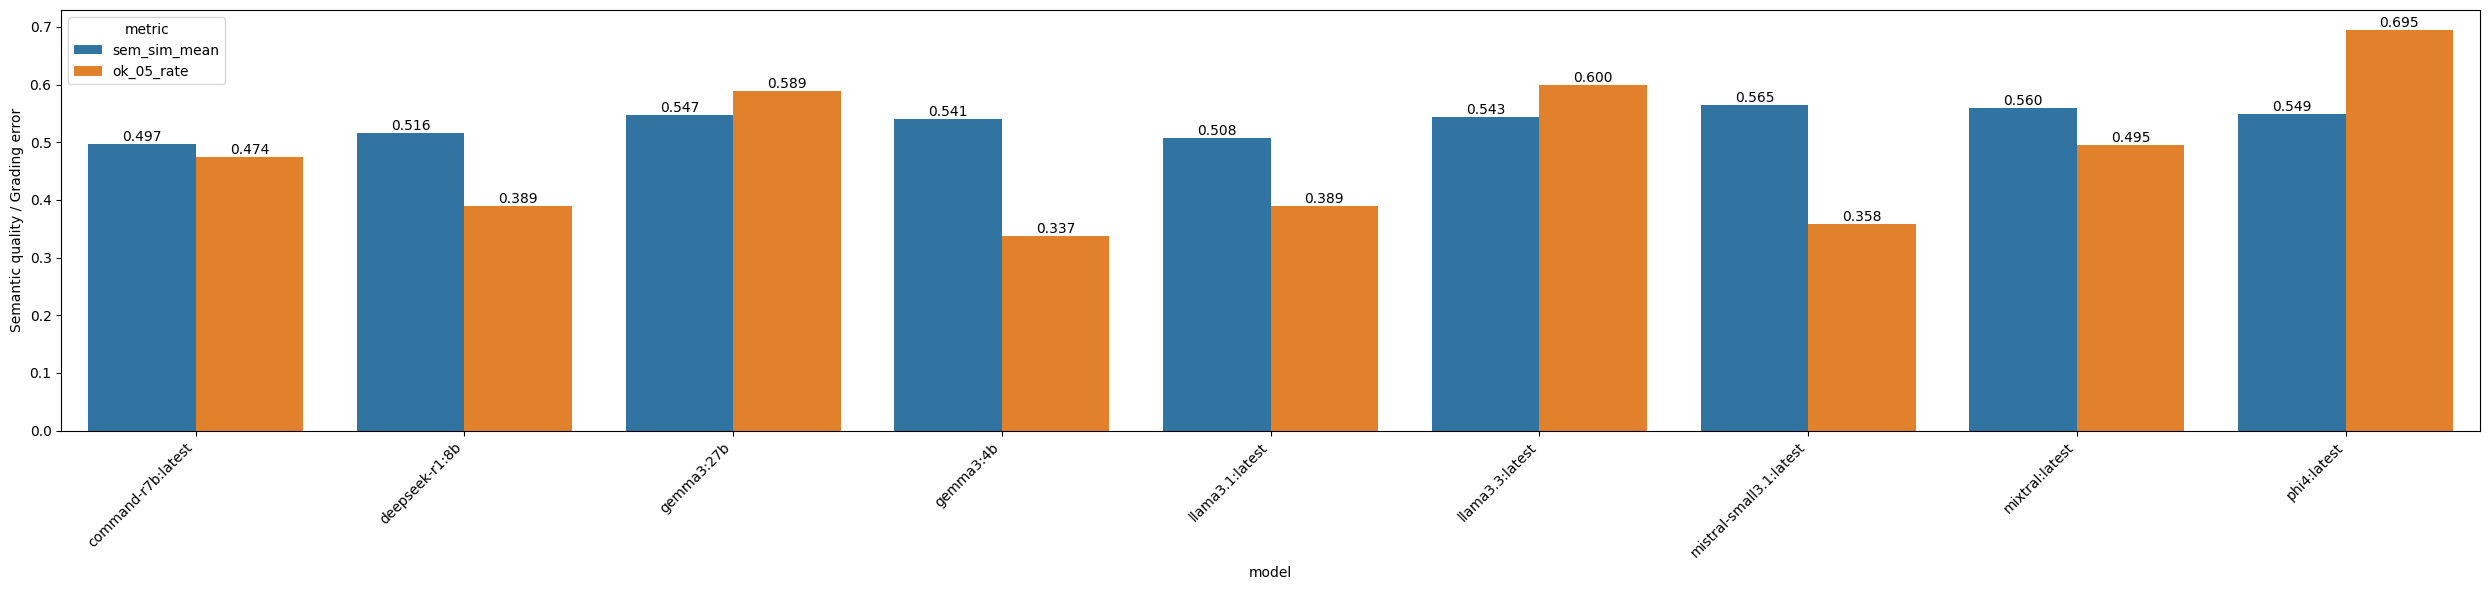

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_05_rate"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(25, 6))

ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

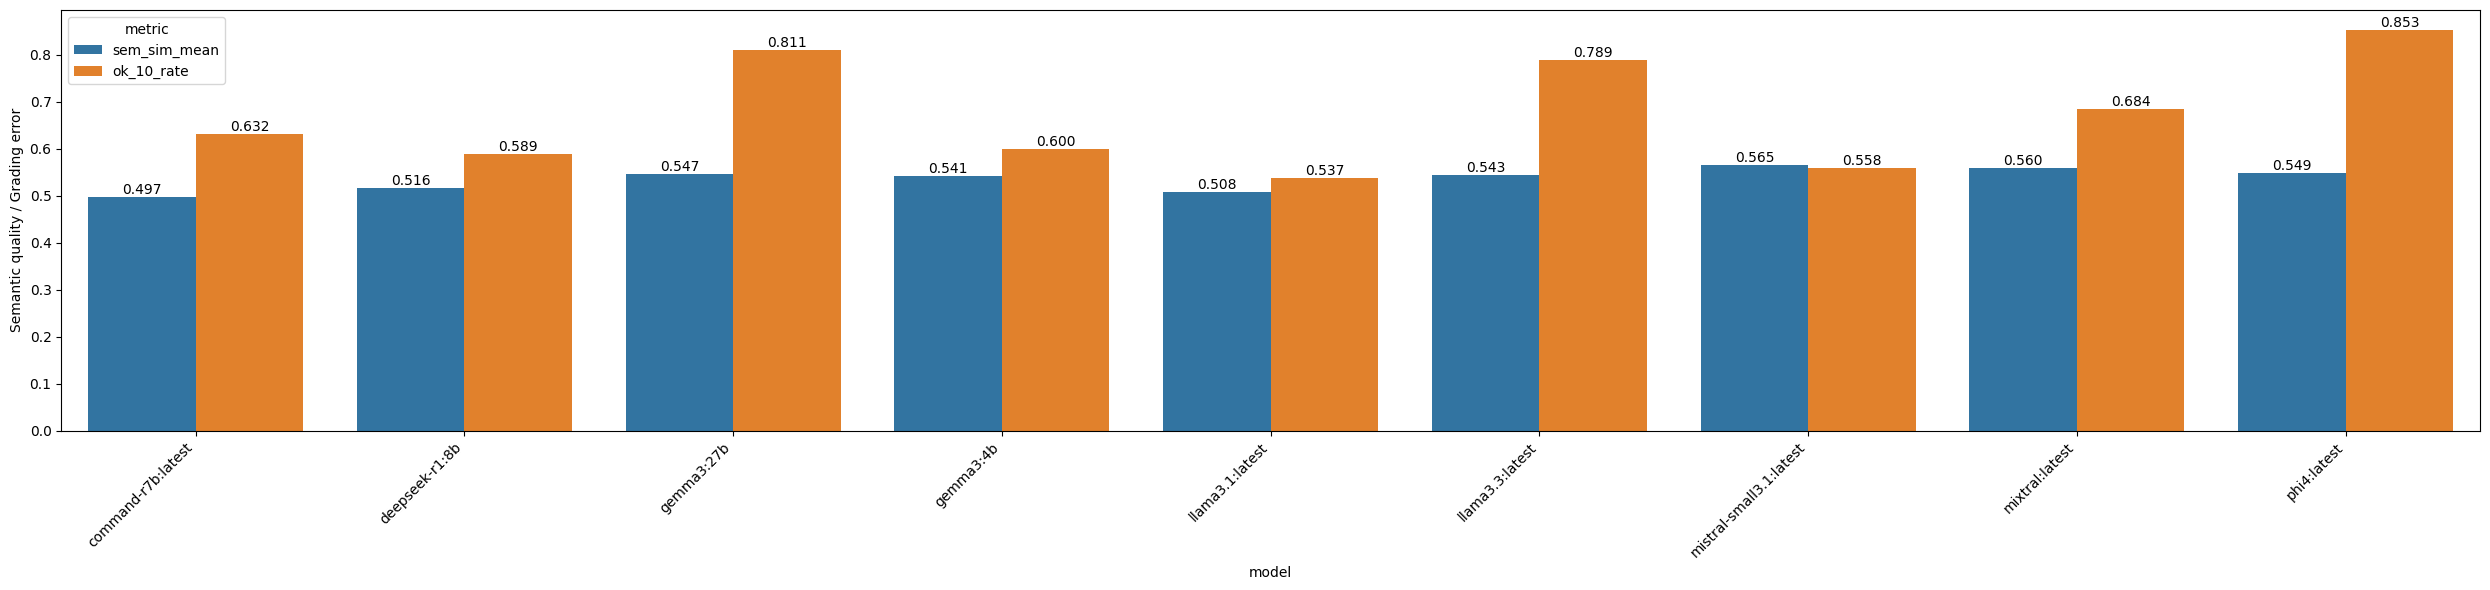

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_10_rate"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(25, 6))

ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()